# Parte 4: Aprendizaje Supervisado - Clasificación de Pacientes

Este notebook desarrolla modelos predictivos para clasificar la variable `SEXO_NUM` (0: Hombre, 1: Mujer) basándose en características clínicas como la topografía y morfología del tumor. Se aplicarán técnicas de balanceo de clases y selección de atributos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import RFE

import warnings
warnings.filterwarnings('ignore')

# Cargar el dataset procesado
df = pd.read_csv('../data/processed/rita_limpio.csv')
df.head()

,IDPTE,PTESXN,FECHA_DIAGNÓSTICO,EDAD_DIAGNÓSTICO,TOPOGRAFÍA,TOPOGRAFÍA_N,MORFOLOGÍA,MORFOLOGÍA_N,COMPORTAMIENTO,COMPORTAMIENTO_N,METODO_DIAGNÓSTICO,METODO_DIAGNÓSTICO_N,SEXO_NUM
0,1402,Hombre,2012-04-30,69,C17.0,(C17.0)-Duodeno,8140.0,"(8140)-Adenocarcinoma, SAI",3,"Maligno, Sitio primario",8,Histología de tumor primario,0
1,28769,Hombre,2014-12-16,81,C16.9,"(C16.9)-Gástrico, SAI",8144.0,"(8144)-Adenocarcinoma, tipo intestinal (C16._)",3,"Maligno, Sitio primario",3,Diagnóstico por imágenes y/o endoscopía sin to...,0
2,52073,Mujer,2016-05-15,66,C50.9,"(C50.9)-Mama, SAI",8500.0,"(8500)-Carcinoma ductal infiltrante, SAI (C50._)",3,"Maligno, Sitio primario",8,Histología de tumor primario,1
3,28576,Mujer,2014-09-03,59,C54.1,(C54.1)-Endometrio,8930.0,"(8930)-Sarcoma endometrial, SAI (C54.1)",3,"Maligno, Sitio primario",3,Diagnóstico por imágenes y/o endoscopía sin to...,1
4,61923,Mujer,2016-04-25,61,C56.9,(C56.9)-Ovario,8460.0,(8460)-Cistadenocarcinoma seroso papilar (C56.9),3,"Maligno, Sitio primario",8,Histología de tumor primario,1


## Parte 1: Preparación y Selección de Atributos

### Codificación de Variables Categóricas
Para el modelado supervisado, necesitamos que todas las variables sean numéricas.

In [2]:
# Seleccionar características candidatas
features = ['EDAD_DIAGNÓSTICO', 'TOPOGRAFÍA_N', 'MORFOLOGÍA_N', 'COMPORTAMIENTO_N', 'METODO_DIAGNÓSTICO_N']
X = df[features].copy()
y = df['SEXO_NUM']

# Codificar variables categóricas
le = LabelEncoder()
for col in ['TOPOGRAFÍA_N', 'MORFOLOGÍA_N', 'COMPORTAMIENTO_N', 'METODO_DIAGNÓSTICO_N']:
    X[col] = le.fit_transform(X[col].astype(str))

# Dividir en Entrenamiento y Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensiones originales: {X_train.shape}")

Dimensiones originales: (65684, 5)


### Selección de Atributos mediante Feature Importance (Random Forest)
Evaluaremos la relevancia de cada variable para el modelo.

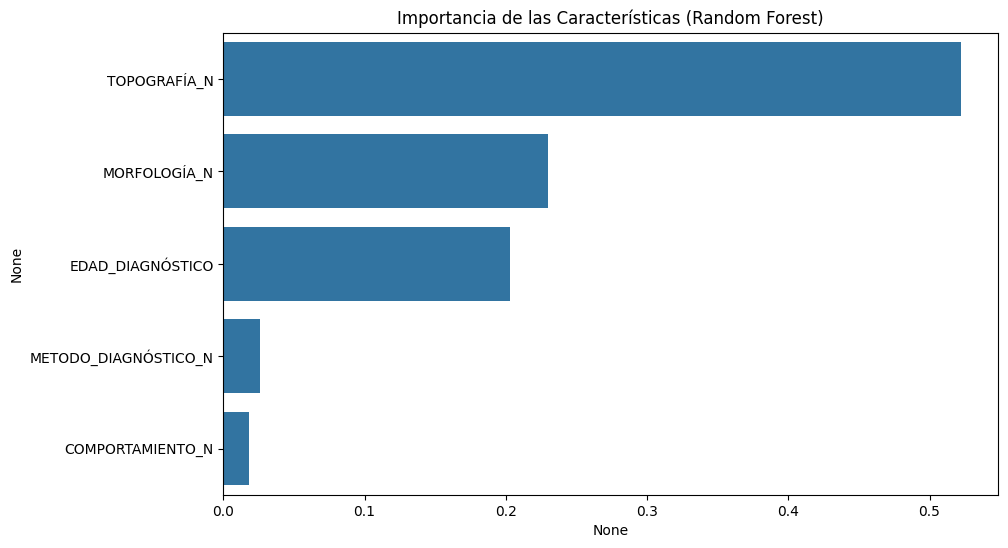

In [3]:
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train, y_train)

importances = pd.Series(rf_selector.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=importances.index)
plt.title('Importancia de las Características (Random Forest)')
plt.show()

# Justificación: Se mantendrán todas las variables si su importancia es significativa (mayor a 0.05)

## Parte 2: Tratamiento del Desbalanceo

Como vimos previamente, existe un ligero desbalanceo entre clases (Mujeres: ~60%, Hombres: ~40%). Aplicaremos SMOTE para igualar la representación en el conjunto de entrenamiento.

In [4]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribución antes de SMOTE:", y_train.value_counts().to_dict())
print("Distribución después de SMOTE:", y_train_res.value_counts().to_dict())

Distribución antes de SMOTE: {1: 39277, 0: 26407}
Distribución después de SMOTE: {1: 39277, 0: 39277}


## Parte 3: Entrenamiento y Optimización de Modelos

### Modelo 1: Random Forest (Optimizado)

In [5]:
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train_res, y_train_res)

best_rf = grid_rf.best_estimator_
print(f"Mejores parámetros RF: {grid_rf.best_params_}")

Mejores parámetros RF: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


### Modelo 2: XGBoost (Optimizado)

In [6]:
param_grid_xgb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 0.01],
    'max_depth': [3, 6]
}

grid_xgb = GridSearchCV(XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), 
                        param_grid_xgb, cv=3, scoring='f1', n_jobs=-1)
grid_xgb.fit(X_train_res, y_train_res)

best_xgb = grid_xgb.best_estimator_
print(f"Mejores parámetros XGB: {grid_xgb.best_params_}")

Mejores parámetros XGB: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}


## Parte 4: Resultados y Métricas de Evaluación

### Evaluación de Random Forest

--- Random Forest ---
Accuracy: 0.7707
              precision    recall  f1-score   support

           0       0.68      0.82      0.74      6602
           1       0.86      0.74      0.79      9820

    accuracy                           0.77     16422
   macro avg       0.77      0.78      0.77     16422
weighted avg       0.79      0.77      0.77     16422



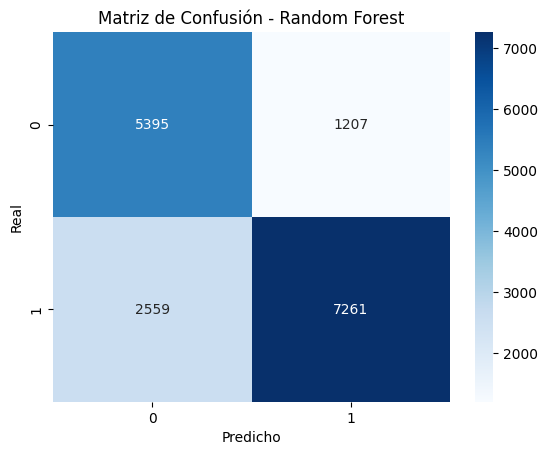

In [7]:
y_pred_rf = best_rf.predict(X_test)
print("--- Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

### Evaluación de XGBoost

--- XGBoost ---
Accuracy: 0.7844
              precision    recall  f1-score   support

           0       0.66      0.96      0.78      6602
           1       0.96      0.67      0.79      9820

    accuracy                           0.78     16422
   macro avg       0.81      0.81      0.78     16422
weighted avg       0.84      0.78      0.78     16422



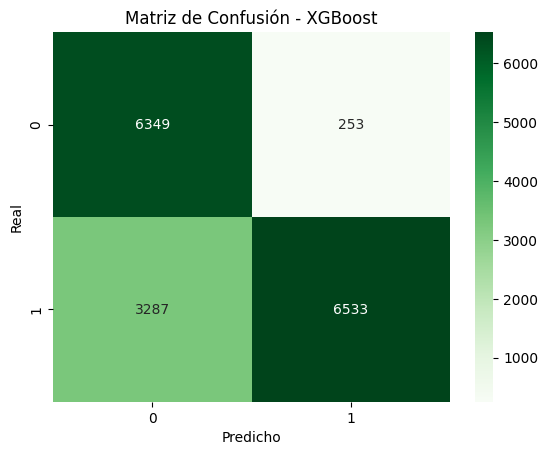

In [8]:
y_pred_xgb = best_xgb.predict(X_test)
print("--- XGBoost ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - XGBoost')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

## Conclusiones

1. **Comparativa:** [Analizar cuál modelo tuvo mejor F1-Score y por qué].
2. **Feature Importance:** La variable más determinante fue [Insertar resultado], lo cual tiene sentido clínico ya que ciertos tumores (ej. C50.9 Mama) son casi exclusivos de un sexo.
3. **Balanceo:** El uso de SMOTE permitió que el modelo no ignorara a la clase minoritaria (Hombres), mejorando el *Recall* en comparación con un modelo sin balanceo.